In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import h5py
import scipy.sparse as sp
import yaml
import scanpy as sc
import scanpy.external as sce
import gget
import time
import pyranges as pr

import logging

# Load data

In [2]:
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/hsc_epi2me_full/anndata/gene_adata.h5ad"
# fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/hsc_epi2me_full/anndata/gene_adata_hac_only.h5ad"
adata = sc.read_h5ad(fpath)
sc.logging.print_memory_usage()
adata

Memory usage: current 0.96 GB, difference +0.96 GB


AnnData object with n_obs × n_vars = 11403 × 25311
    obs: 'hac_v3', 'fast_v4.2', 'fast_v3', 'minion_384', 'hac_v4.3', 'hac_v4.2'
    var: 'hac_v3', 'fast_v4.2', 'fast_v3', 'minion_384', 'hac_v4.3', 'hac_v4.2'

In [3]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

adata

AnnData object with n_obs × n_vars = 11403 × 25311
    obs: 'hac_v3', 'fast_v4.2', 'fast_v3', 'minion_384', 'hac_v4.3', 'hac_v4.2', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'hac_v3', 'fast_v4.2', 'fast_v3', 'minion_384', 'hac_v4.3', 'hac_v4.2', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

# Filtering

In [4]:
sc.pp.filter_cells(adata, min_counts=200)
sc.pp.filter_genes(adata, min_counts=10)

adata.layers['counts'] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

adata.layers['log_norm'] = adata.X.copy()
adata

AnnData object with n_obs × n_vars = 8540 × 21969
    obs: 'hac_v3', 'fast_v4.2', 'fast_v3', 'minion_384', 'hac_v4.3', 'hac_v4.2', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts'
    var: 'hac_v3', 'fast_v4.2', 'fast_v3', 'minion_384', 'hac_v4.3', 'hac_v4.2', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts'
    uns: 'log1p'
    layers: 'counts', 'log_norm'

# Plotting

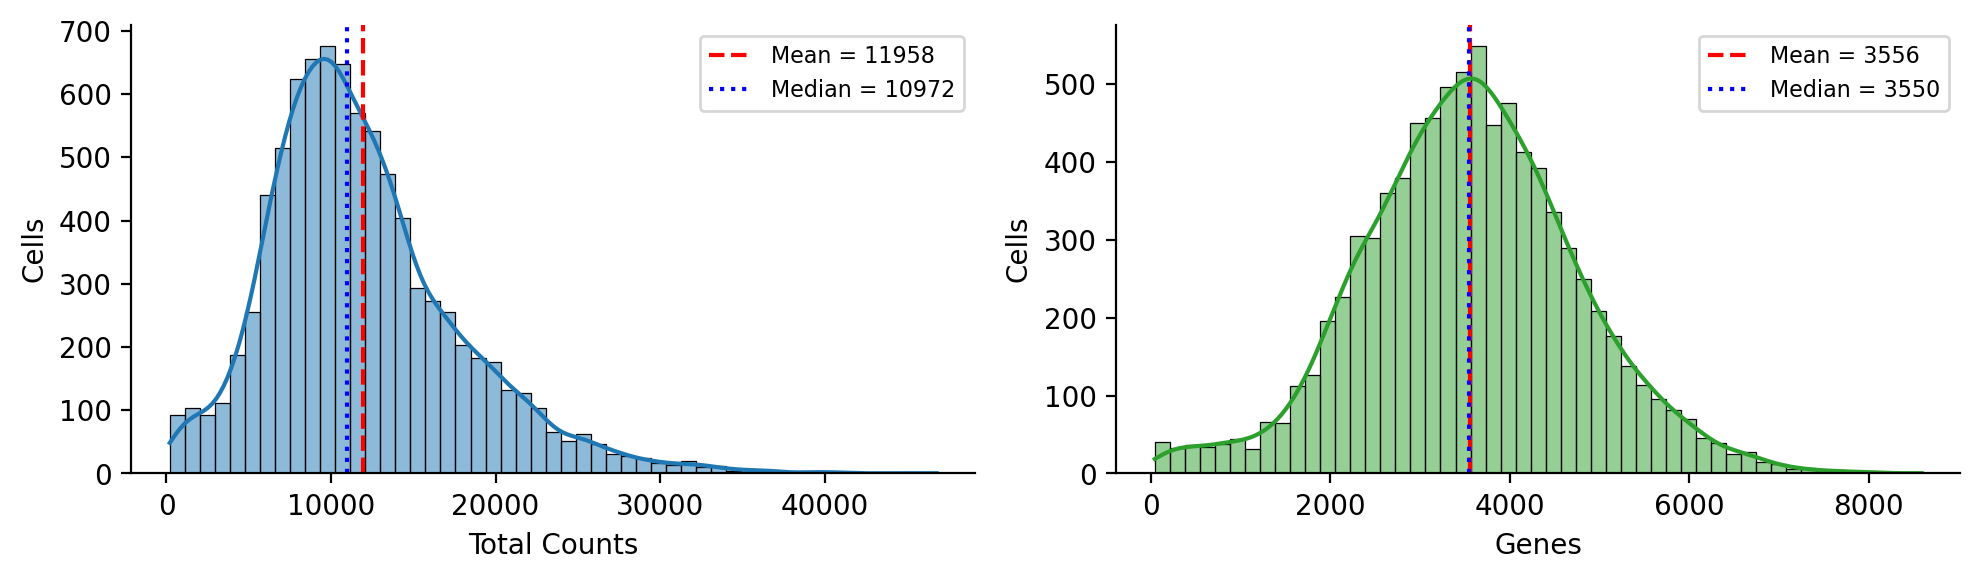

In [5]:
# Set style and figure size
plt.rcParams['figure.dpi'] = 200
fig, axes = plt.subplots(1, 2, figsize=(10, 3))  # 1 row, 2 columns

# --- First Histogram: Total Counts ---
col1 = 'total_counts'
data1 = adata.obs[col1]
mean1 = data1.mean()
median1 = data1.median()

sns.histplot(
    data=data1,
    bins=51,
    kde=True,
    ax=axes[0]
)
axes[0].axvline(mean1, color='red', linestyle='--', label=f'Mean = {mean1:.0f}')
axes[0].axvline(median1, color='blue', linestyle=':', label=f'Median = {median1:.0f}')
axes[0].legend(fontsize=8)
axes[0].set_xlabel('Total Counts')
axes[0].set_ylabel('Cells')
sns.despine(ax=axes[0])

# --- Second Histogram: Number of Genes ---
col2 = 'n_genes_by_counts'
data2 = adata.obs[col2]
mean2 = data2.mean()
median2 = data2.median()

sns.histplot(
    data=data2,
    bins=51,
    kde=True,
    color="C2",
    ax=axes[1]
)
axes[1].axvline(mean2, color='red', linestyle='--', label=f'Mean = {mean2:.0f}')
axes[1].axvline(median2, color='blue', linestyle=':', label=f'Median = {median2:.0f}')
axes[1].legend(fontsize=8)
axes[1].set_xlabel('Genes')
axes[1].set_ylabel('Cells')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

In [6]:
# break

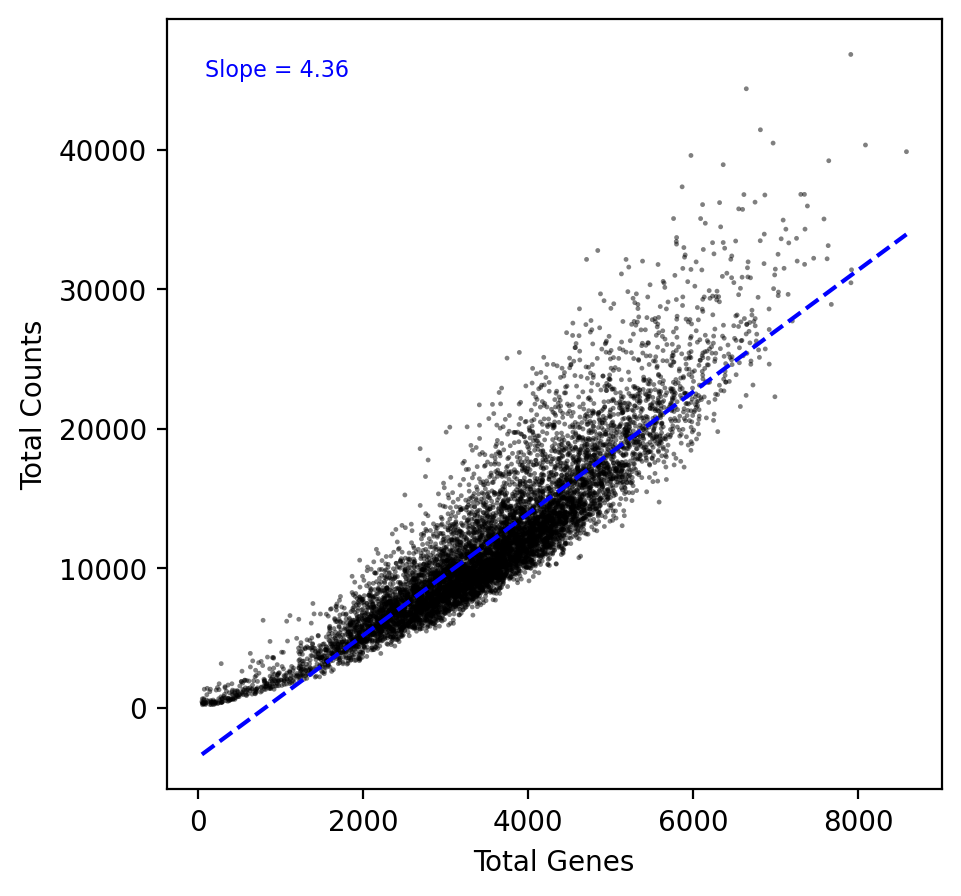

In [7]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 5

# Extract x and y
x = adata.obs['n_genes_by_counts']
y = adata.obs['total_counts']

# Scatterplot
sns.scatterplot(
    x=x,
    y=y,
    ec='none',
    s=3,
    alpha=0.5,
    c='k',
)

# Fit a regression line
slope, intercept = np.polyfit(x, y, 1)
x_vals = np.array([x.min(), x.max()])
y_vals = intercept + slope * x_vals

# Plot regression line
plt.plot(x_vals, y_vals, color='b', linewidth=1.5, ls="--")

# Annotate slope
plt.text(
    0.05, 0.95,
    f'Slope = {slope:.2f}',
    transform=plt.gca().transAxes,
    ha='left',
    va='top',
    color='b',
    fontsize=8,
)

# Labels
plt.ylabel('Total Counts')
plt.xlabel('Total Genes')

# Show plot
plt.show()

# Feature Selection

Number of genes before HVG selection: 21969
Number of HVGs: 3206


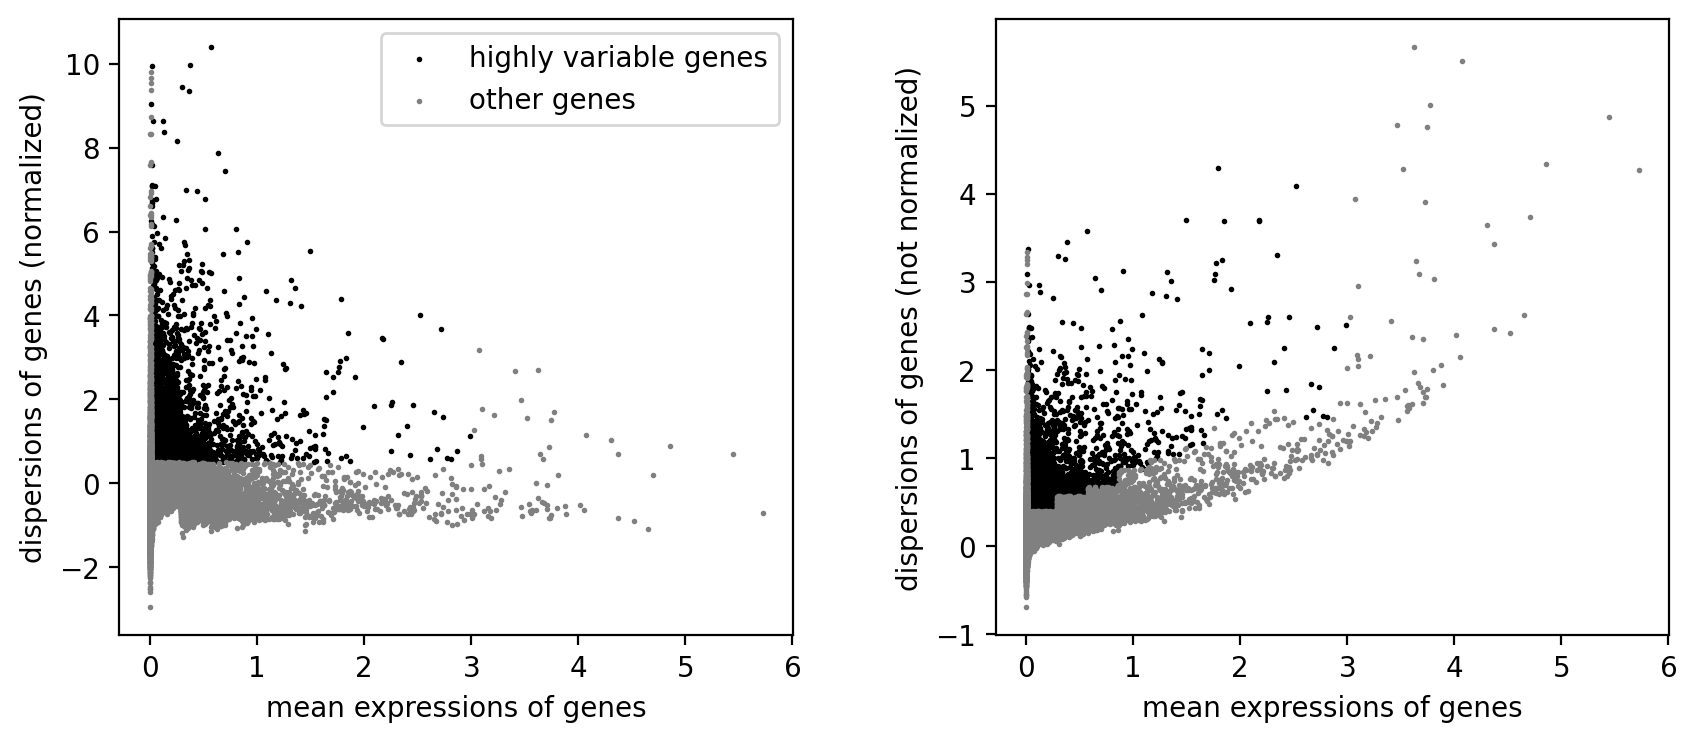

AnnData object with n_obs × n_vars = 8540 × 21969
    obs: 'hac_v3', 'fast_v4.2', 'fast_v3', 'minion_384', 'hac_v4.3', 'hac_v4.2', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts'
    var: 'hac_v3', 'fast_v4.2', 'fast_v3', 'minion_384', 'hac_v4.3', 'hac_v4.2', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'
    layers: 'counts', 'log_norm'

In [8]:
adata.raw = adata  # keep full dimension safe
print(f"Number of genes before HVG selection: {adata.n_vars}")

sc.pp.highly_variable_genes(
    adata, 
)

print(f"Number of HVGs: {adata.var['highly_variable'].sum()}")

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 4
sc.pl.highly_variable_genes(
    adata
)

adata

# PCA and Clustering

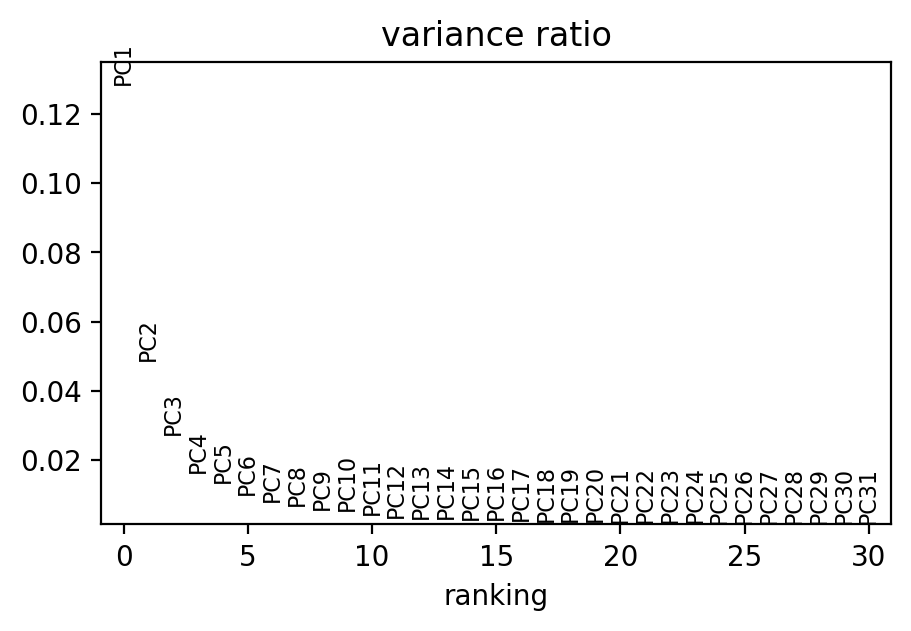

AnnData object with n_obs × n_vars = 8540 × 21969
    obs: 'hac_v3', 'fast_v4.2', 'fast_v3', 'minion_384', 'hac_v4.3', 'hac_v4.2', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts'
    var: 'hac_v3', 'fast_v4.2', 'fast_v3', 'minion_384', 'hac_v4.3', 'hac_v4.2', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts', 'log_norm'

In [9]:
sc.pp.pca(
    adata,
)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 3
sc.pl.pca_variance_ratio(
    adata
)

adata

/tmp/ipykernel_368593/1466380444.py:13: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


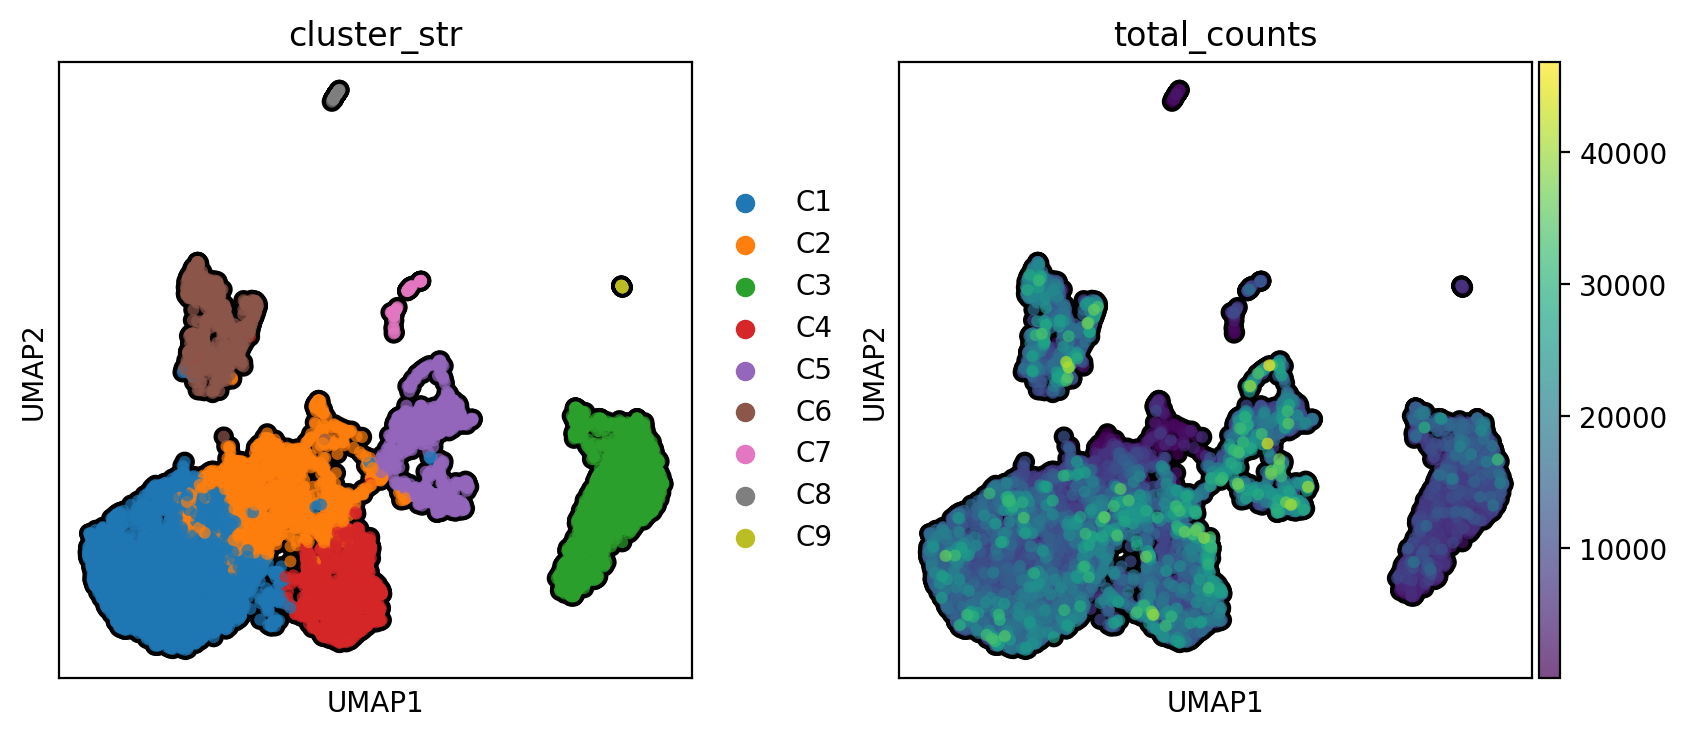

In [10]:
sc.pp.neighbors(
    adata,
    n_neighbors=7,
    n_pcs=10,
    
)

sc.tl.umap(
    adata,
    min_dist=0.15,
)

sc.tl.leiden(
    adata,
    resolution=0.15,
)

adata.obs['cluster_str'] = adata.obs['leiden'].apply(lambda x: f"C{str(int(x) + 1)}")

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    color=['cluster_str', 'total_counts',],
    size=75,
    ncols=2,
    add_outline=True,
    outline_color=('k', 'k'),
)

# Write the Data

In [11]:
# coords = pd.DataFrame({
#     'cell_id' : adata.obs.index,
#     'UMAP_1' : adata.obsm['X_umap'][:, 0],
#     'UMAP_2' : adata.obsm['X_umap'][:, 1],
# })

# print(f"{coords.shape=}")

# adata.uns['coords'] = coords
# adata

In [12]:
# outpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/hsc_epi2me_full/anndata/gene_adata_processed.h5ad"
# adata.write(outpath)
# adata

# Gene Expression Analysis

In [18]:
adata

AnnData object with n_obs × n_vars = 8540 × 21969
    obs: 'hac_v3', 'fast_v4.2', 'fast_v3', 'minion_384', 'hac_v4.3', 'hac_v4.2', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'leiden', 'cluster_str'
    var: 'hac_v3', 'fast_v4.2', 'fast_v3', 'minion_384', 'hac_v4.3', 'hac_v4.2', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'cluster_str_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 

In [27]:
hsc_genes = [
     "GATA2", "STAT5A", "REL", "FOS", 
]

df = adata.to_df(layer='counts')
df = df[hsc_genes].astype(bool).astype(int)
df = df.sum(axis=0).reset_index()

print(df.to_latex(index=False))

\begin{tabular}{lr}
\toprule
index & 0 \\
\midrule
GATA2 & 2599 \\
STAT5A & 1231 \\
REL & 4545 \\
FOS & 5005 \\
\bottomrule
\end{tabular}



4 kept
['GATA2', 'STAT5A', 'REL', 'FOS']


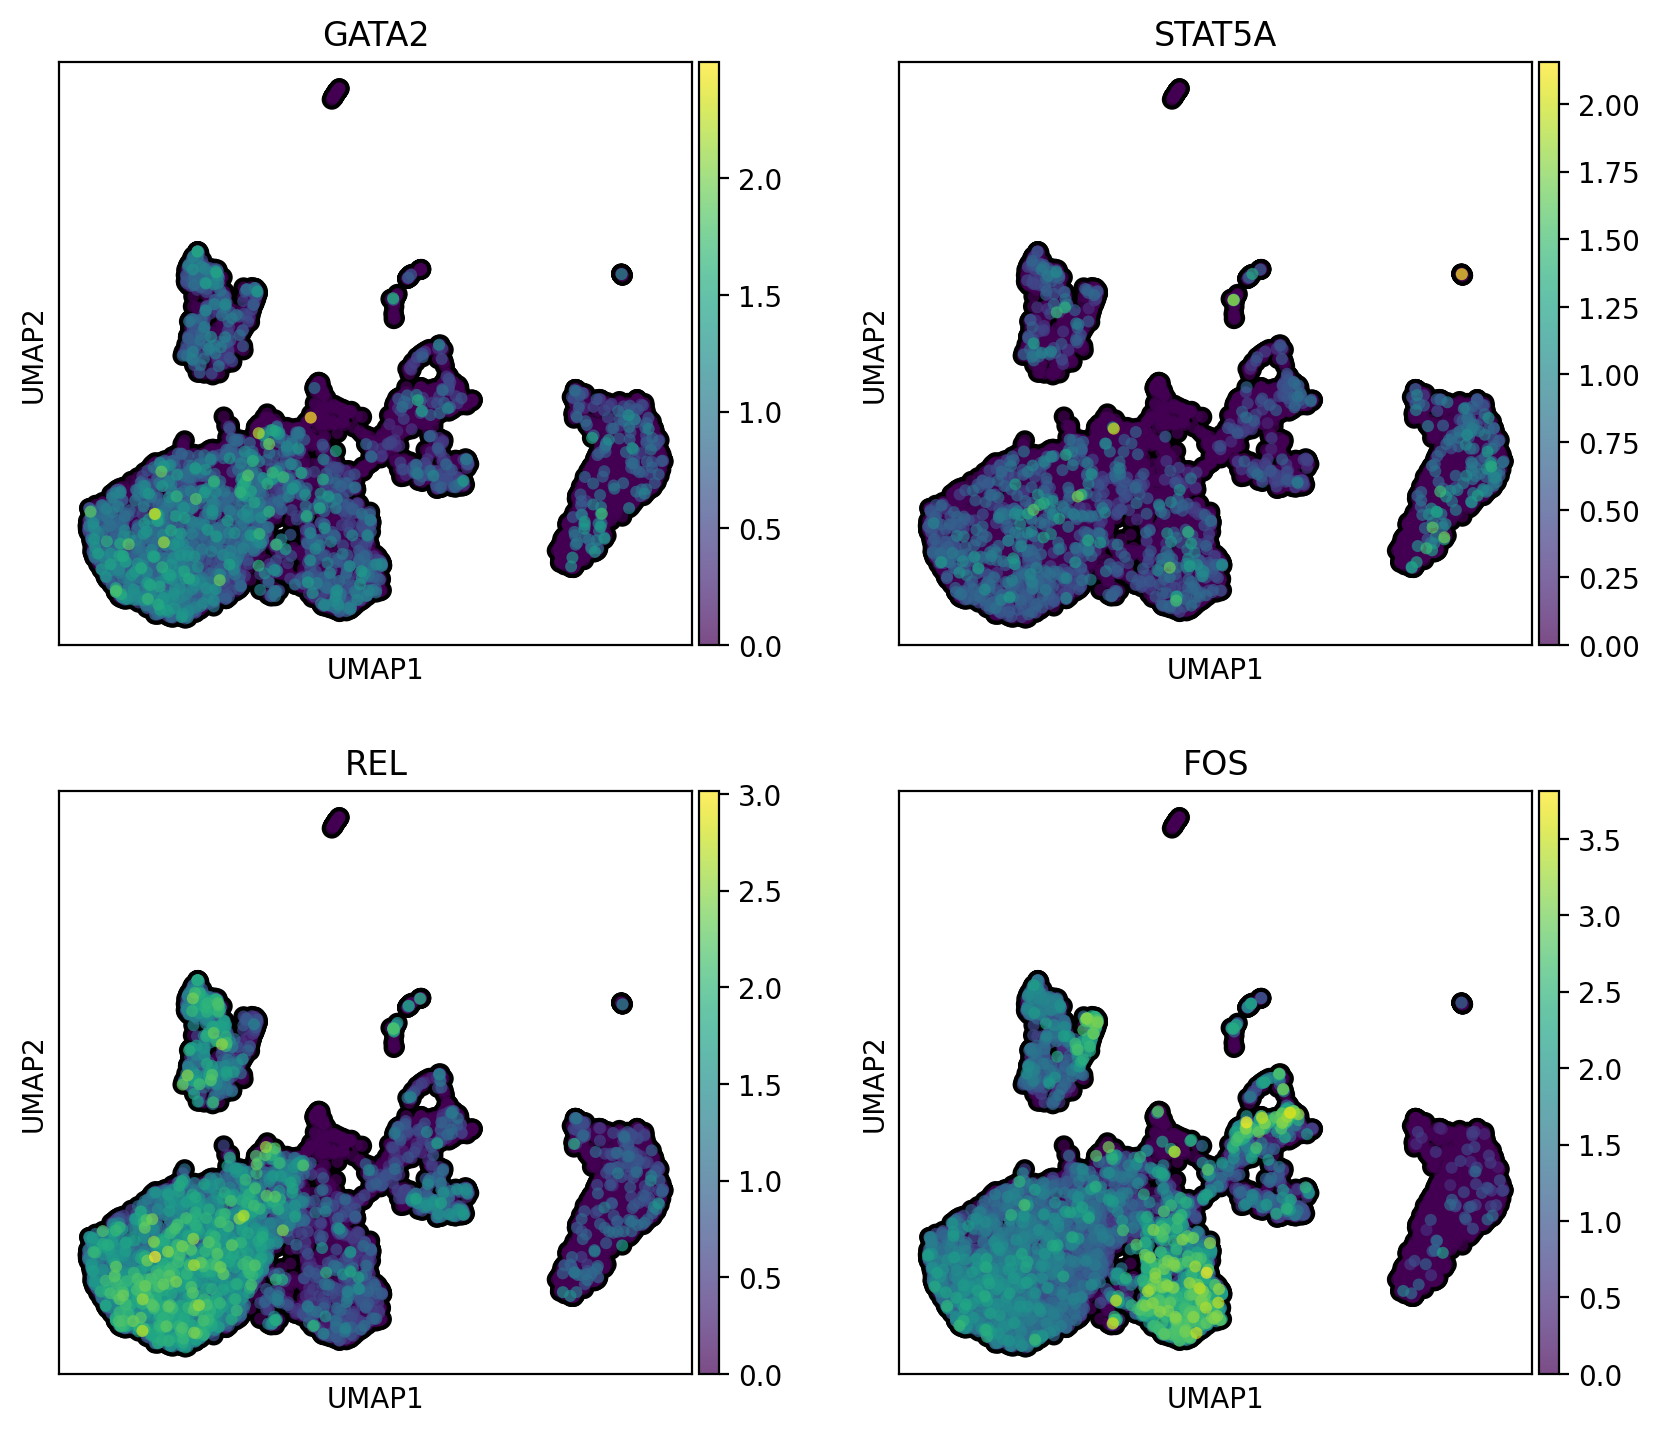

In [13]:
hsc_genes = [
     "GATA2", "STAT5A", "REL", "FOS",
]

hsc_genes = [x for x in hsc_genes if x in adata.var_names]
print(f"{len(hsc_genes)} kept")
print(hsc_genes)

sc.pl.umap(
    adata,
    color=hsc_genes,
    size=75,
    ncols=2,
    add_outline=True,
    outline_color=('k', 'k'),
    
)


6 kept
['RUNX1', 'MEIS1', 'ERG', 'CD34', 'ANGPT1', 'KITLG']


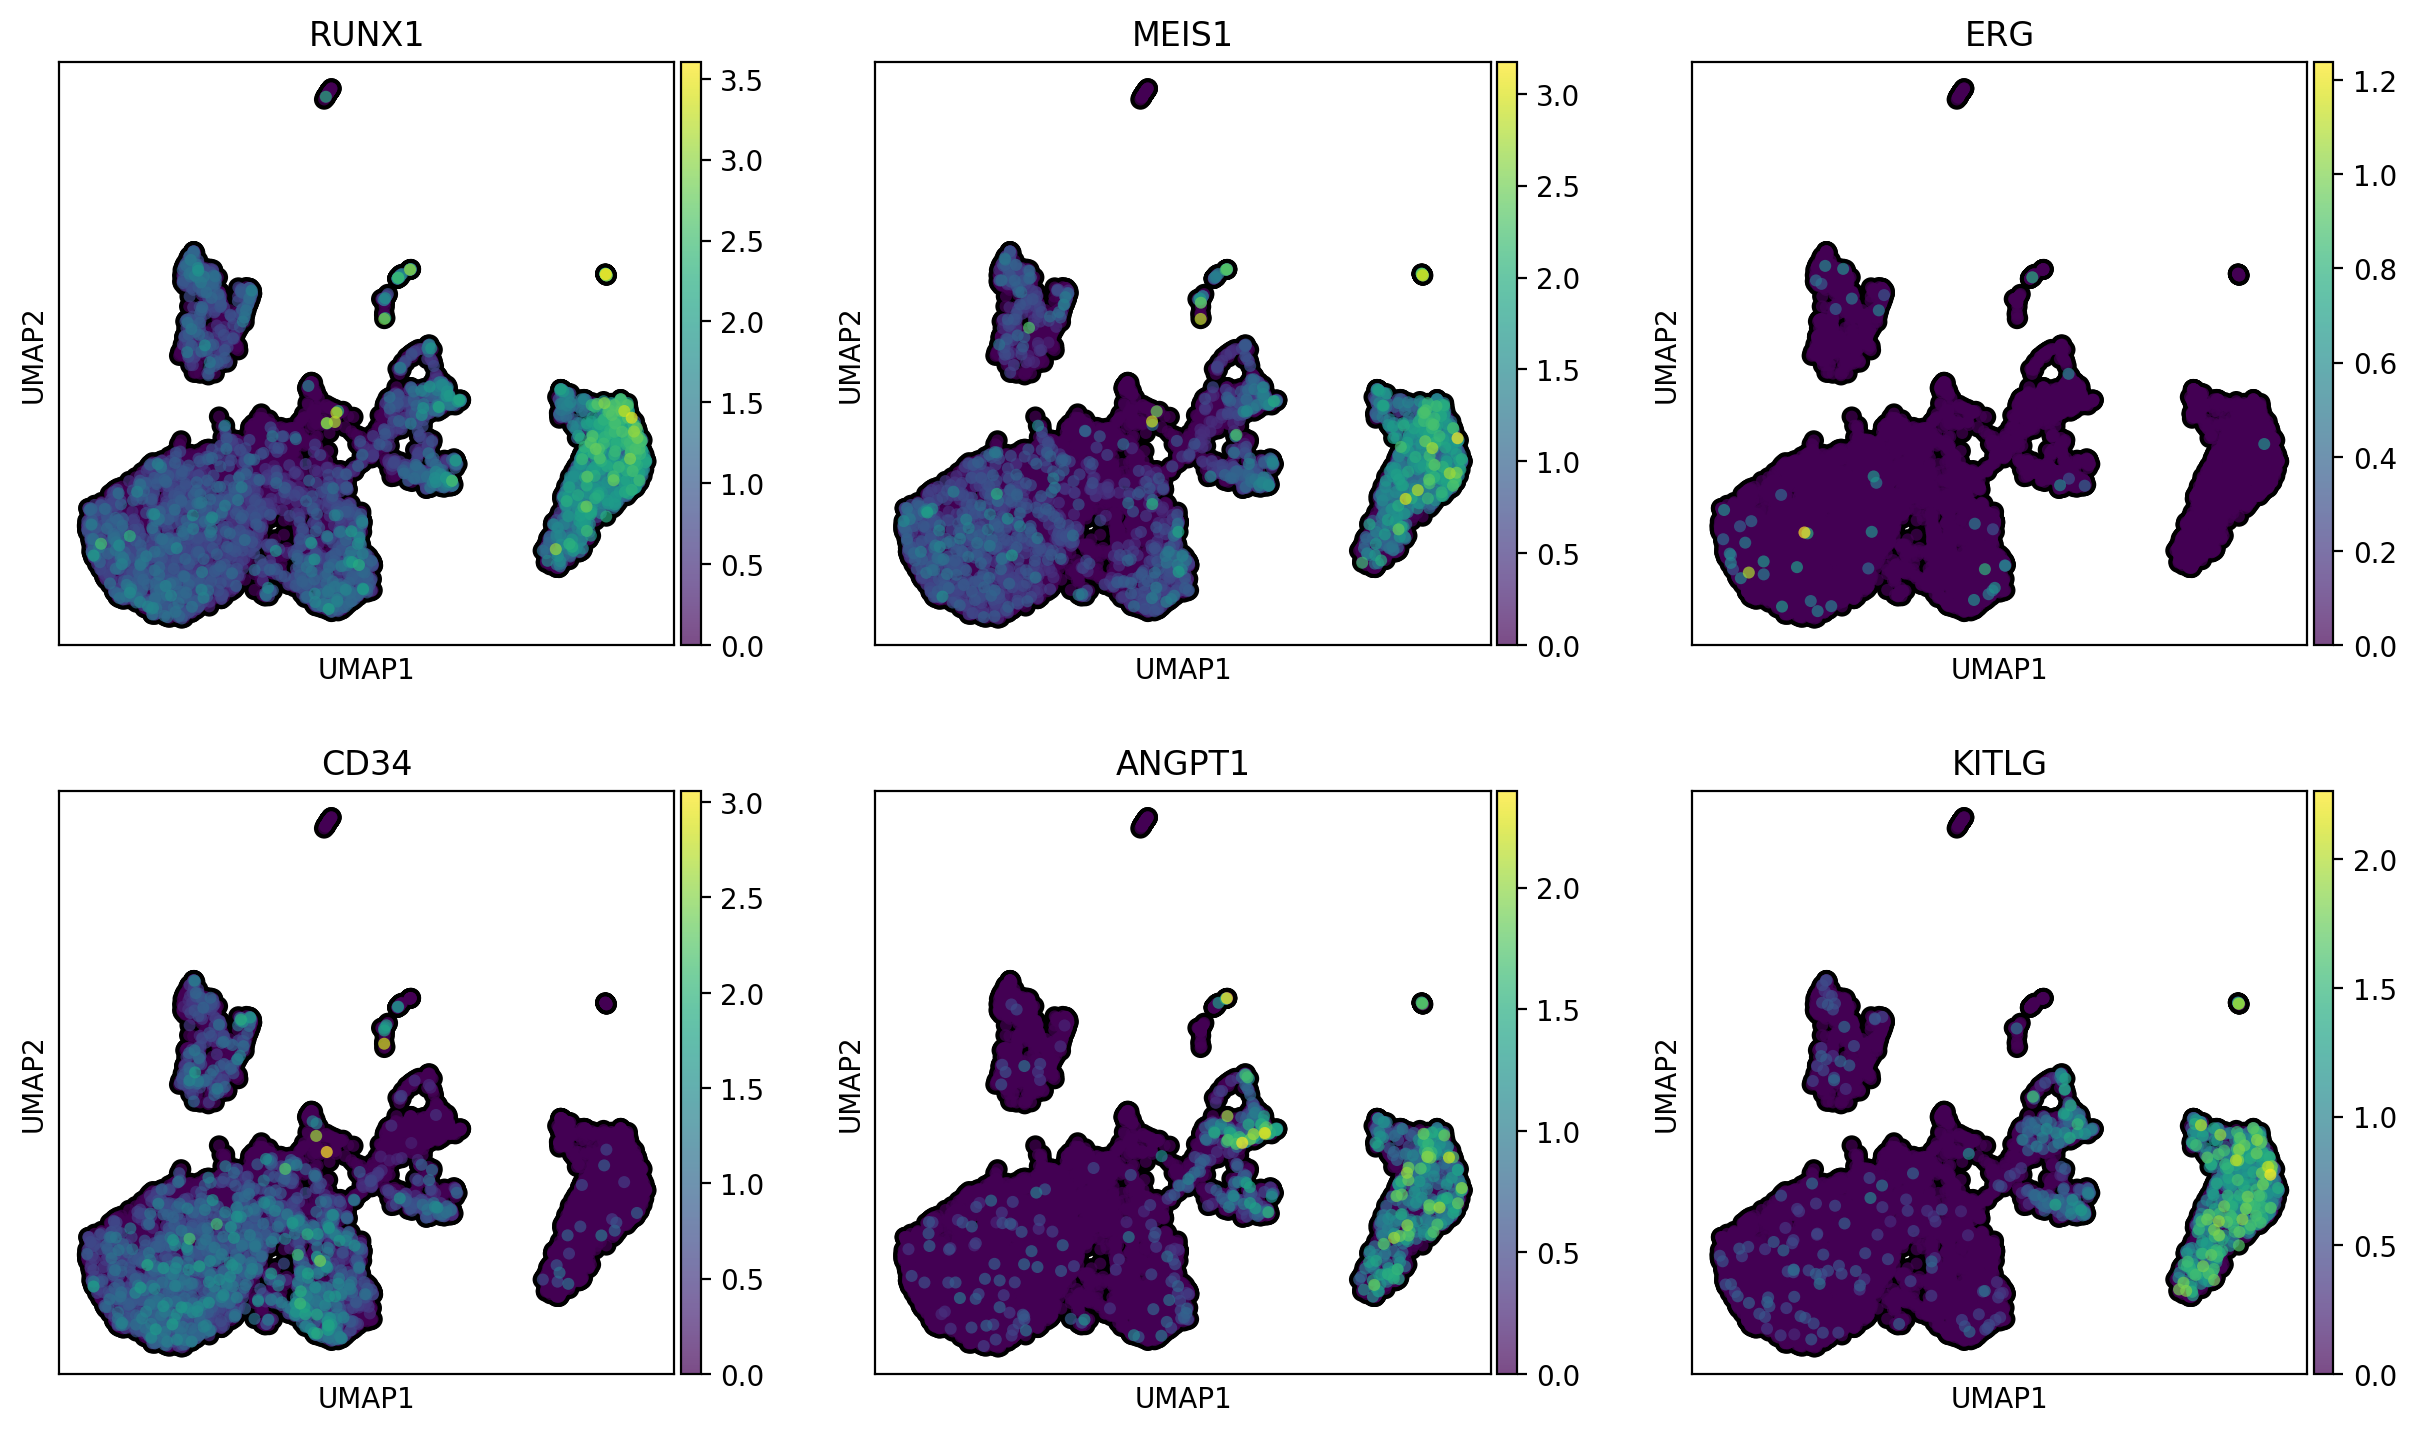

In [14]:
hsc_genes = [
    "RUNX1", "MEIS1", "ERG","CD34","ANGPT1", "KITLG",
]

hsc_genes = [x for x in hsc_genes if x in adata.var_names]
print(f"{len(hsc_genes)} kept")
print(hsc_genes)

sc.pl.umap(
    adata,
    color=hsc_genes,
    size=75,
    ncols=3,
    add_outline=True,
    outline_color=('k', 'k'),

)


In [15]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
hsc_genes = [
    # Transcription factors
    "RUNX1", "GATA2", "TAL1", "LMO2", "HOXA9", "MEIS1", "MYB", "ERG",
    
    # Surface markers
    "CD34", "CD38", "CD90", "CD45RA", "CD49f", "CD133", "CD117", "CD105", "CD150", "CD48",
    
    # Stemness and quiescence
    "BMI1", "HES1", "NR4A1", "FOXO3", "MPL", "TEK", "THY1",
    
    # Cell cycle and DNA repair
    "TP53", "ATM", "BRCA1", "CHEK2", "CDKN1A", "CDKN2A", "E2F2",
    
    # Niche interaction and signaling
    "CXCR4", "ANGPT1", "KITLG", "TPO", "SCF", "JAK2", "NOTCH1", "DLL4", "JAG1", "WNT3A", "FZD7",
    
    # Epigenetic regulators
    "DNMT3A", "TET2", "ASXL1", "EZH2", "MLL1", "BCOR", "IDH1", "IDH2"
]

hsc_genes = [x for x in hsc_genes if x in adata.var_names]
print(f"{len(hsc_genes)} kept")
print(hsc_genes)

sc.pl.umap(
    adata,
    color=hsc_genes,
    size=75,
    ncols=2,
    add_outline=True,
    outline_color=('k', 'k'),

)


In [ ]:
endothelial_genes = [
    # Surface markers
    "PECAM1", "CDH5", "VWF", "MCAM", "ESAM", "ENG", "ICAM1", "VCAM1", "CD34",

    # Transcription factors
    "ERG", "FOXC2", "GATA2", "SOX17", "ETV2", "NRP1",

    # Signaling and angiogenesis
    "KDR", "FLT1", "TIE1", "TEK", "ANGPT1", "ANGPT2", "VEGFA", "VEGFC", "DLL4", "JAG1", "NOTCH4",

    # Junction proteins
    "CLDN5", "OCLN", "TJP1", "CDH5",

    # Extracellular matrix and response to flow
    "NOS3", "EDN1", "THBD", "SELE", "PDGFB"
]

endothelial_genes = [x for x in endothelial_genes if x in adata.var_names]
print(f"{len(endothelial_genes)} kept")
print(endothelial_genes)

sc.pl.umap(
    adata,
    color=endothelial_genes,
    size=75,
    ncols=2,
    add_outline=True,
    outline_color=('k', 'k'),

)


In [ ]:
fibroblast_genes = [
    # Surface markers
    "PDGFRA", "PDGFRB", "THY1", "CD90", "FSP1", "S100A4", "CD44", "VIM",

    # Transcription factors
    "TWIST1", "ZEB1", "TCF21", "FOXC1", "GLI1",

    # ECM production and remodeling
    "COL1A1", "COL1A2", "COL3A1", "FN1", "LOX", "MMP2", "MMP9", "TIMP1", "TIMP2",

    # Cytoskeletal and contractile proteins
    "ACTA2", "TAGLN", "MYH11", "CNN1",

    # Fibrosis and TGF-β signaling
    "TGFB1", "TGFBR1", "SMAD2", "SMAD3", "CTGF", "POSTN"
]

fibroblast_genes = [x for x in fibroblast_genes if x in adata.var_names]
print(f"{len(fibroblast_genes)} kept")
print(fibroblast_genes)

sc.pl.umap(
    adata,
    color=fibroblast_genes,
    size=75,
    ncols=2,
    add_outline=True,
    outline_color=('k', 'k'),

)


In [ ]:
# break

# Imputation

In [ ]:
sce.pp.magic(adata, solver='approximate')
adata.layers['magic'] = adata.X.copy()
adata.X = adata.layers['log_norm'].copy()
adata

In [ ]:
hsc_genes = [
    "RUNX1", "GATA2", "MEIS1", "CD34", 
]

hsc_genes = [x for x in hsc_genes if x in adata.var_names]
print(f"{len(hsc_genes)} kept")
print(hsc_genes)

sc.pl.umap(
    adata,
    color=hsc_genes,
    size=75,
    ncols=2,
    add_outline=True,
    outline_color=('k', 'k'),
)


# Differential Expression

In [ ]:
sc.tl.rank_genes_groups(
    adata, 
    groupby="cluster_str",
    method='wilcoxon',
    corr_method='benjamini-hochberg',
    pts=True,
)

deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
)

deg.head()

In [ ]:
def filter_deg(deg, alpha=0.01, lfc=1):
    print(f" - Starting DEG filtering with alpha={alpha}, log2FC>{lfc}")
    sig = deg.copy()
    
    initial_count = len(sig)
    print(f" - Total genes before filtering: {initial_count}")
    
    sig = sig[sig['pvals_adj'] <= alpha]
    after_pval_filter = len(sig)
    print(f" - Genes with adjusted p-value <= {alpha}: {after_pval_filter}")
    
    sig = sig[sig['logfoldchanges'] > lfc].reset_index(drop=True)
    after_lfc_filter = len(sig)
    print(f" - Genes with log2 fold change > {lfc}: {after_lfc_filter}")
    
    sig = sig.sort_values(by=['group', 'logfoldchanges'], ascending=[True, False])
    print(f" - Final gene count after filtering: {len(sig)}")
    return sig
    
sig = filter_deg(deg)
sig.head()

In [ ]:
n_genes = 5

for group_id, group_df in sig.groupby('group'):
    gene_list = group_df['names'].head(n_genes).to_list()
    print(gene_list)

    gene_list = ['cluster_str'] + gene_list
    
    sc.pl.umap(
        adata,
        color=gene_list,
        size=75,
        ncols=3,
        add_outline=True,
        outline_color=('k', 'k'),
        frameon=False,
    )
    break

In [ ]:
?sc.pl.umap

In [ ]:
n_genes = 50
database = 'celltypes'

print(f"Running Enrichment on {n_genes} genes using database: {database}")

logging.getLogger().setLevel(logging.ERROR)

for group_id, group_df in sig.groupby('group'):
    gene_list = group_df['names'].head(n_genes).to_list()
    edf = gget.enrichr(
        gene_list,
        database=database,
    )

    edf = edf[['path_name', 'adj_p_val', 'overlapping_genes']]
    print(f"\n----- cluster {group_id}  -----")
    print(edf.head().to_string(index=False))
    time.sleep(2)

In [ ]:
n_genes = 50
database = 'ontology'

print(f"Running Enrichment on {n_genes} genes using database: {database}")


for group_id, group_df in sig.groupby('group'):
    gene_list = group_df['names'].head(n_genes).to_list()
    edf = gget.enrichr(
        gene_list,
        database=database,
    )

    edf = edf[['path_name', 'adj_p_val', 'overlapping_genes']]
    print(f"\n----- cluster {group_id}  -----")
    print(edf.head().to_string(index=False))
    time.sleep(2)

In [ ]:
break